# GPCP precipitation analysis (2010)

This notebook loads the GPCP monthly precipitation product for 2010, converts the longitude range from [-180, 180] to [0, 360], saves the result as a single NetCDF file, and produces a set of paper-relevant plots tied to the aerosol analysis (SSA, MAC, MEC, AOD) in the AeroCom project.

**Main variable:** `sat_gauge_precip` (mm/day), the combined satellite-gauge precipitation estimate.

In [10]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, glob
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Robust project-root discovery (works whether the notebook is run from py/ or notebooks/)
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir) if os.path.basename(notebook_dir) in ('py', 'notebooks') else notebook_dir
py_dir = os.path.join(project_root, 'py')

if py_dir not in sys.path:
    sys.path.insert(0, py_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import cameo_toolbox as ct
import aerocom_data

print(f'Project root: {project_root}')
print(f'Python dir:   {py_dir}')

Project root: /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom
Python dir:   /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/py


## 1. Load GPCP monthly files and convert longitude to 0-360

In [11]:
# Load the 12 monthly GPCP files for 2010
prec_files = sorted(glob.glob(os.path.join(project_root, 'Data/Prec', 'GPCPMON_L3_2010*_V3.3.nc4')))
print(f'Found {len(prec_files)} GPCP files')

# Open as a single dataset along the time dimension
gpcp = xr.open_mfdataset(prec_files, combine='nested', concat_dim='time')
print(f'Original lon range: {float(gpcp.lon.min().values):.2f} to {float(gpcp.lon.max().values):.2f}')

# Convert longitude from -180/+180 to 0-360 and sort
gpcp['lon'] = (gpcp['lon'] + 360) % 360
gpcp = gpcp.sortby('lon')
gpcp = gpcp.sortby('time')
print(f'Converted lon range: {float(gpcp.lon.min().values):.2f} to {float(gpcp.lon.max().values):.2f}')

# Save the converted dataset for reuse by other notebooks/scripts
out_path = os.path.join(project_root, 'Data/Prec', 'GPCP_2010_0-360.nc')
if not os.path.exists(out_path):
    gpcp.to_netcdf(out_path)
    print(f'Saved converted dataset to {out_path}')
else:
    print(f'Converted dataset already exists at {out_path}')

print(f'File size: {os.path.getsize(out_path) / 1e6:.2f} MB')
print('\nDataset structure:')
print(gpcp)

Found 12 GPCP files
Original lon range: -179.75 to 179.75
Converted lon range: 0.25 to 359.75
Converted dataset already exists at /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/Prec/GPCP_2010_0-360.nc
File size: 93.36 MB

Dataset structure:
<xarray.Dataset> Size: 112MB
Dimensions:                        (time: 12, lat: 360, lon: 720, bnds: 2)
Coordinates:
  * time                           (time) datetime64[ns] 96B 2010-01-01 ... 2...
  * lat                            (lat) float32 1kB 89.75 89.25 ... -89.75
  * lon                            (lon) float32 3kB 0.25 0.75 ... 359.2 359.8
Dimensions without coordinates: bnds
Data variables:
    sat_gauge_precip               (time, lat, lon) float32 12MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    sat_gauge_random_error         (time, lat, lon) float32 12MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    sat_gauge_absolute_bias_error  (time, lat, lon) float32 12MB dask.array<chunksize=(1, 360, 720

## 2. Create regional masks and compute monthly means

In [12]:
# Main precipitation variable
pr = gpcp['sat_gauge_precip']

# Region definitions consistent with AAOD_error_attribution.ipynb.
# Each entry carries surface_type, lon_range, lat_range, time_slice and
# edge_weighted so that masks and temporal aggregation are configured in one
# place.
REGIONS = {
    'global': {
        'surface_type': 'all',
        'lon_range': (0, 360), 'lat_range': (-90, 90),
        'time_slice': ('2010-01-01', '2010-12-31'), 'edge_weighted': False,
    },
    'africa': {
        'surface_type': 'land',
        'lon_range': (15, 37), 'lat_range': (-15, 0),
        'time_slice': ('2010-06-01', '2010-09-30'), 'edge_weighted': False,
    },
    'amazon': {
        'surface_type': 'land',
        'lon_range': (287, 317), 'lat_range': (-17, -3),
        'time_slice': ('2010-07-01', '2010-10-31'), 'edge_weighted': False,
    },
    'outflow_af': {
        'surface_type': 'ocean',
        'lon_range': (350, 15), 'lat_range': (-15, 0),
        'time_slice': ('2010-06-01', '2010-09-30'), 'edge_weighted': True,
    },
    'west_russia': {
        'surface_type': 'land',
        'lon_range': (33, 52), 'lat_range': (51, 60),
        'time_slice': ('2010-07-15', '2010-09-10'), 'edge_weighted': False,
    },
    'boreal_na_west': {
        'surface_type': 'land',
        'lon_range': (242, 258), 'lat_range': (52, 63),
        'time_slice': ('2010-06-15', '2010-08-31'), 'edge_weighted': False,
    },
}

# Create masks using the same cameo_toolbox helper as AAOD_error_attribution.
# Named regions resolve to the default lat/lon boxes and surface types in
# cameo_toolbox._REGION_DEFINITIONS.
mask_registry = {}
for name, cfg in REGIONS.items():
    mask_registry[name] = ct.create_region_mask(
        pr, region=name,
        surface_type=cfg['surface_type'],
        mask_registry=mask_registry,
    )

# Compute area-weighted monthly means for each region
ts_dict = {}
for region, cfg in REGIONS.items():
    ts = ct.regional_aggregate(
        pr, mask_registry[region], spatial='mean',
        edge_weighted=cfg['edge_weighted'],
        time_slice=cfg['time_slice'],
        return_time_series=True,
    )
    ts_dict[region] = ts.to_series()
    print(f'{region:12s}: mean = {ts_dict[region].mean():.3f} mm/day')

global      : mean = 3.075 mm/day
africa      : mean = 1.105 mm/day
amazon      : mean = 1.896 mm/day
outflow_af  : mean = 0.354 mm/day
west_russia : mean = 1.783 mm/day
boreal_na_west: mean = 2.409 mm/day


## 3. Global/annual mean precipitation map for 2010

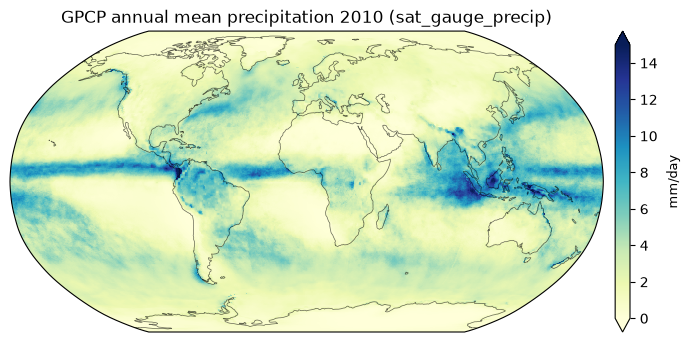

In [13]:
# Global annual mean map using cameo_toolbox.uba_map_flex with a curved (Robinson) projection.
pr_mean = pr.mean(dim='time')
ct.uba_map_flex(
    data=pr_mean,
    title='GPCP annual mean precipitation 2010 (sat_gauge_precip)',
    projection_type='curved',
    extent='global',
    mycolor='YlGnBu',
    vmin=0, vmax=15,
    cbar_title='mm/day',
    savefile=os.path.join(project_root, 'notebooks', 'GPCP_annual_mean_2010.png'),
    show=False,
)
plt.show()

## 4. Monthly time series of global and tropical mean precipitation

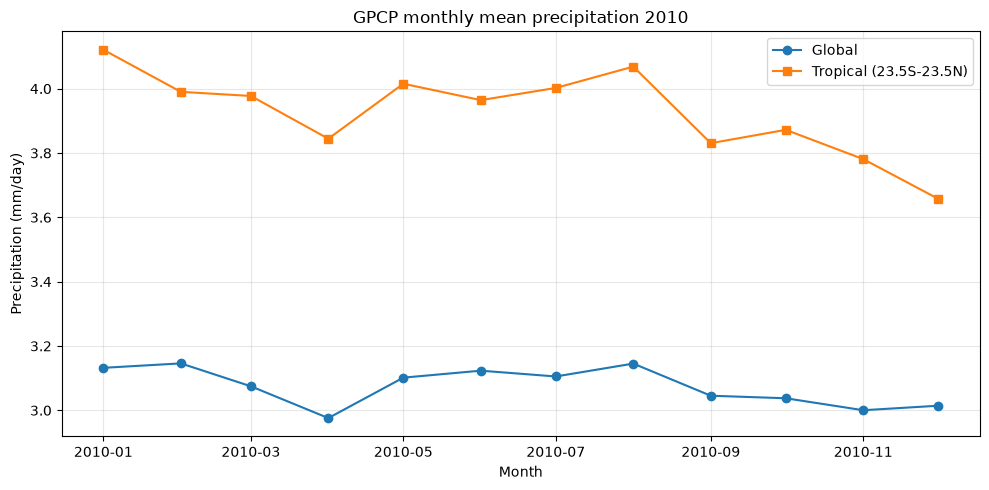

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts_dict['global'].index, ts_dict['global'].values, 'o-', label='Global', color='tab:blue')

# Tropical belt 23.5S-23.5N
trop_mask = ct.create_region_mask(pr, region='tropical', lon_range=(0, 360), lat_range=(-23.5, 23.5))
ts_trop = ct.regional_aggregate(pr, trop_mask, spatial='mean', time_slice=slice('2010-01-01', '2010-12-31'), return_time_series=True)
ax.plot(ts_trop.time.to_index(), ts_trop.values, 's-', label='Tropical (23.5S-23.5N)', color='tab:orange')

ax.set_xlabel('Month')
ax.set_ylabel('Precipitation (mm/day)')
ax.set_title('GPCP monthly mean precipitation 2010')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(project_root, 'notebooks', 'GPCP_monthly_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Regional precipitation maps for the study regions

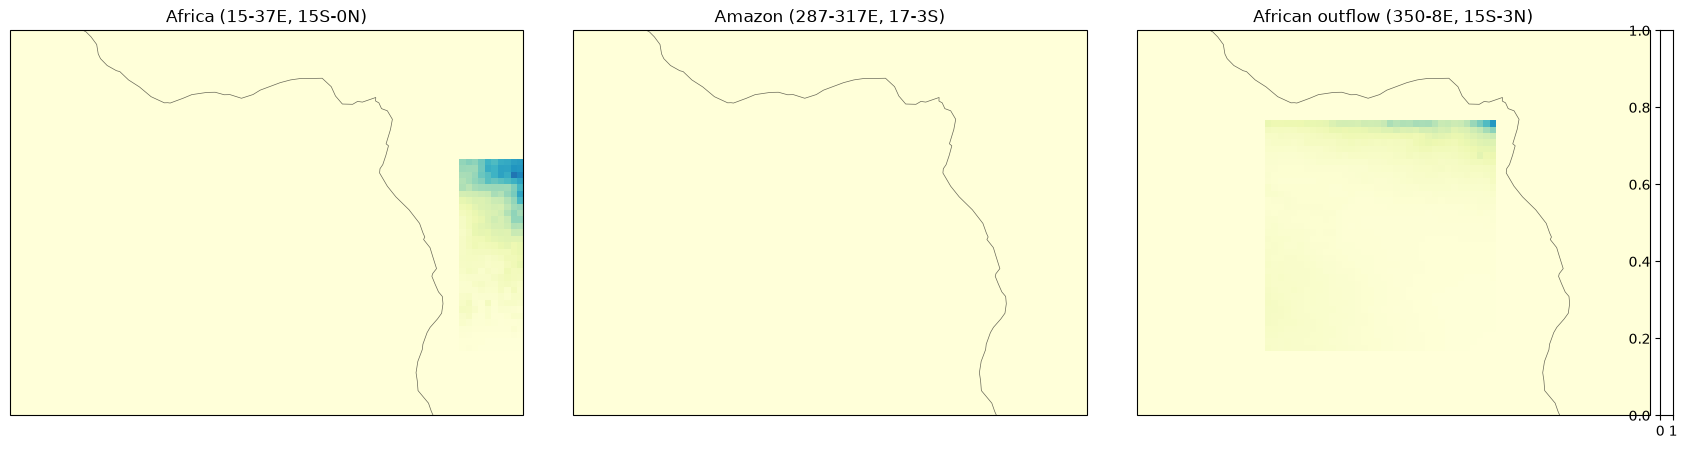

In [15]:
# Regional maps using cameo_toolbox.uba_map_flex.
# We use a local PlateCarree projection for each regional box so the study
# areas are shown without the distortion of a global curved projection.
regional_fields = {}
regional_extents = {
    'Africa (15-37E, 15S-0N)': [5, 47, -25, 10],
    'Amazon (287-317E, 17-3S)': [275, 330, -25, 5],
    'African outflow (350-8E, 15S-3N)': [340, 20, -20, 10],
}
for region, title in zip(['africa', 'amazon', 'outflow_af'], regional_extents.keys()):
    mask = mask_registry[region]
    tslice = slice(*REGIONS[region]['time_slice'])
    regional_fields[title] = (pr * mask).sel(time=tslice).mean(dim='time')

ct.uba_map_flex(
    data=regional_fields,
    projection_type='regular',
    extent=regional_extents,
    mycolor='YlGnBu',
    vmin=0, vmax=8,
    cbar_title='mm/day',
    savefile=os.path.join(project_root, 'notebooks', 'GPCP_regional_maps.png'),
    show=False,
)
plt.show()

## 5b. Multi-model median vs GPCP precipitation (Fig. S4 style, median-based)

This section replicates the style of Fig. S4 in Zhong et al. 2023 (Sci. Adv., adi3568),
comparing AeroCom multi-model precipitation with GPCP observations for the Amazon
(July–October 2010) and Southern Africa (June–September 2010). Each dot represents
the monthly average precipitation over a 1°×1° GPCP grid box, paired with the
co-located multi-model value.

**Methodological notes (deviations from the original figure):**
- **Central value:** We use the **multi-model median** (not the mean/average as in the
  original figure), which is more robust to outlier models and skewed distributions.
- **Error bars:** Since we use the median as the central estimate, we use the
  **interquartile range (25th–75th percentile)** instead of standard deviation for
  the error bars, consistent with the median as a more distribution-appropriate summary.
- **Loading path:** AeroCom model data is loaded from the pre-built pickle
   for speed.
  All 19 models with a  variable are included (vs. 17 in the original paper).
- **Collocation:** Models are bilinearly interpolated to the 0.5°×0.5° GPCP grid;
  each (month, lat, lon) grid box constitutes one data point per scatter panel.
- Precip units in model files are kg m⁻² s⁻¹; we convert to mm/day (×86400).


In [21]:
from scipy.stats import pearsonr

# ── Load model precipitation from processed NetCDF files ──────────────────────
print('Loading model precipitation from processed NetCDF files...')
raw_data = aerocom_data.load_monthly_data_from_netcdf(
    output_base_dir=os.path.join(project_root, 'Data', 'AP3_processed_monthly'),
    variables=['precip'],
)

models = sorted(raw_data.keys())
print(f'Number of models: {len(models)}')

# Normalize time coordinates and precipitation units to mm/day (same helpers
# as AAOD_error_attribution.ipynb).
def normalize_dataset_time(ds, var_hint=None):
    """Normalize time coordinate to first-of-month."""
    return aerocom_data.normalize_dataset_time(ds, var_hint=var_hint, year=2010)


def normalize_precipitation_units(precip_ds):
    """Convert model precipitation to mm day^-1.

    Handles kg/m2/s, g/m2/s, and the typo 'km m-2 s-1' seen in ECHAM6.3-HAM2.3.
    Also applies a sanity check: if the global mean is > 100 mm/day after the
    stated-unit conversion, the file is likely in g/m2/s despite the label.
    """
    if precip_ds is None:
        return None
    var_name = list(precip_ds.data_vars)[0]
    da = precip_ds[var_name]
    units = da.attrs.get('units', 'kg m-2 s-1').lower().replace(' ', '')
    if units in ('kgm-2s-1', 'kgm^-2s^-1', 'kg/m2/s', 'kgm-2s-1'):
        factor = 86400.0
    elif units in ('gm-2s-1', 'gm^-2s^-1', 'g/m2/s', 'gm-2s-1'):
        factor = 86.4
    elif units in ('mmday-1', 'mm/day', 'mmday^-1', 'mmd-1'):
        factor = 1.0
    elif units in ('ms-1', 'm/s', 'm s-1'):
        factor = 86400.0 * 1000.0
    else:
        # 'km m-2 s-1' is treated as a typo for kg m^-2 s^-1
        factor = 86400.0
    da = da * factor
    try:
        global_mean = float(da.mean().values)
    except Exception:
        global_mean = np.nan
    if not np.isnan(global_mean) and global_mean > 100.0:
        da = da / 1000.0
    da.attrs['units'] = 'mm day-1'
    return da.to_dataset(name=var_name)


model_precip = {}
for m in models:
    if raw_data[m].get('precip') is None:
        continue
    try:
        ds = normalize_dataset_time(raw_data[m]['precip'], var_hint=f'{m}/precip')
        ds = normalize_precipitation_units(ds)
        model_precip[m] = ds
    except Exception as e:
        print(f'  Failed to normalize {m}/precip: {e}')

models_with_precip = sorted(model_precip.keys())
print(f'Models with precip data: {len(models_with_precip)}')

# ── Region labels for Fig. S4 panels ────────────────────────────────────────
fig_s4_regions = {
    'amazon': {'panel': '(a)', 'label': 'Amazon'},
    'africa': {'panel': '(b)', 'label': 'Africa'},
    'outflow_af': {'panel': '(c)', 'label': 'African outflow'},
}

# ── Compute per-grid-box scatter data for each region ───────────────────────
# Sort GPCP lat ascending for region selection (GPCP files use descending lat)
pr_sorted = pr.sortby('lat')
scatter_data = {}   # region_name -> dict with gpcp, median, iqr arrays

for region_name, cfg in REGIONS.items():
    lon_min, lon_max = cfg['lon_range']
    lat_min, lat_max = cfg['lat_range']
    tidx = slice(*cfg['time_slice'])

    # GPCP: subset to region and analysis window (handle wraparound longitudes)
    if lon_min <= lon_max:
        gpcp_sub = pr_sorted.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max), time=tidx)
    else:
        gpcp_w = pr_sorted.sel(lon=slice(lon_min, 360), lat=slice(lat_min, lat_max), time=tidx)
        gpcp_e = pr_sorted.sel(lon=slice(0, lon_max), lat=slice(lat_min, lat_max), time=tidx)
        gpcp_sub = xr.concat([gpcp_w, gpcp_e], dim='lon')
    ref_lat = gpcp_sub.lat.values
    ref_lon = gpcp_sub.lon.values
    gpcp_arr = gpcp_sub.values   # (n_time, n_lat, n_lon), mm/day

    # Model data: interpolate each model to the GPCP subset grid
    model_arrays = []
    for mname in models_with_precip:
        p = model_precip[mname]
        p_var = list(p.data_vars)[0]
        p_da = p[p_var]
        p_season = p_da.sel(time=tidx)
        p_regrid = p_season.interp(lat=ref_lat, lon=ref_lon, method='linear')
        model_arrays.append(np.array(p_regrid.values, dtype=float))

    if not model_arrays:
        continue

    arr = np.array(model_arrays)  # (n_models, n_time, n_lat, n_lon)

    # Multi-model median and IQR at each (time, lat, lon) point
    med = np.nanmedian(arr, axis=0)
    q25 = np.nanpercentile(arr, 25, axis=0)
    q75 = np.nanpercentile(arr, 75, axis=0)

    # Flatten to 1-D; keep only valid (non-NaN, non-negative) pairs
    g = gpcp_arr.ravel()
    m = med.ravel()
    e_lo = (med - q25).ravel()
    e_hi = (q75 - med).ravel()
    valid = ~np.isnan(g) & ~np.isnan(m) & (g >= 0) & (m >= 0)
    if valid.sum() < 3:
        r_val, p_val = np.nan, np.nan
    else:
        r_val, p_val = pearsonr(g[valid], m[valid])

    scatter_data[region_name] = {
        'gpcp':  g[valid],
        'median': m[valid],
        'e_lo':  e_lo[valid],
        'e_hi':  e_hi[valid],
        'r': r_val,
        'p': p_val,
        'n_models': len(model_arrays),
        'n_pts': int(valid.sum()),
    }
    label = fig_s4_regions.get(region_name, {}).get('label', region_name)
    print(f'{label}: {len(model_arrays)} models, {valid.sum()} grid-box-months, r={r_val:.3f}, p={p_val:.2e}')


Loading model precipitation from processed NetCDF files...
Loaded 22 NetCDF files for 22 models from /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/Data/AP3_processed_monthly
Number of models: 22
Models with precip data: 22
global: 22 models, 3106056 grid-box-months, r=0.884, p=0.00e+00
Africa: 22 models, 5280 grid-box-months, r=0.831, p=0.00e+00
Amazon: 22 models, 6720 grid-box-months, r=0.852, p=0.00e+00
African outflow: 22 models, 5880 grid-box-months, r=0.719, p=0.00e+00
west_russia: 22 models, 1368 grid-box-months, r=0.880, p=0.00e+00
boreal_na_west: 22 models, 1408 grid-box-months, r=0.388, p=1.05e-51


Saved figure to /net/sys/pscst201/IT-ITVO-HPC@ada-nodes/guest/gbb083/AeroCom/notebooks/GPCP_vs_AeroCom_median_precip.png


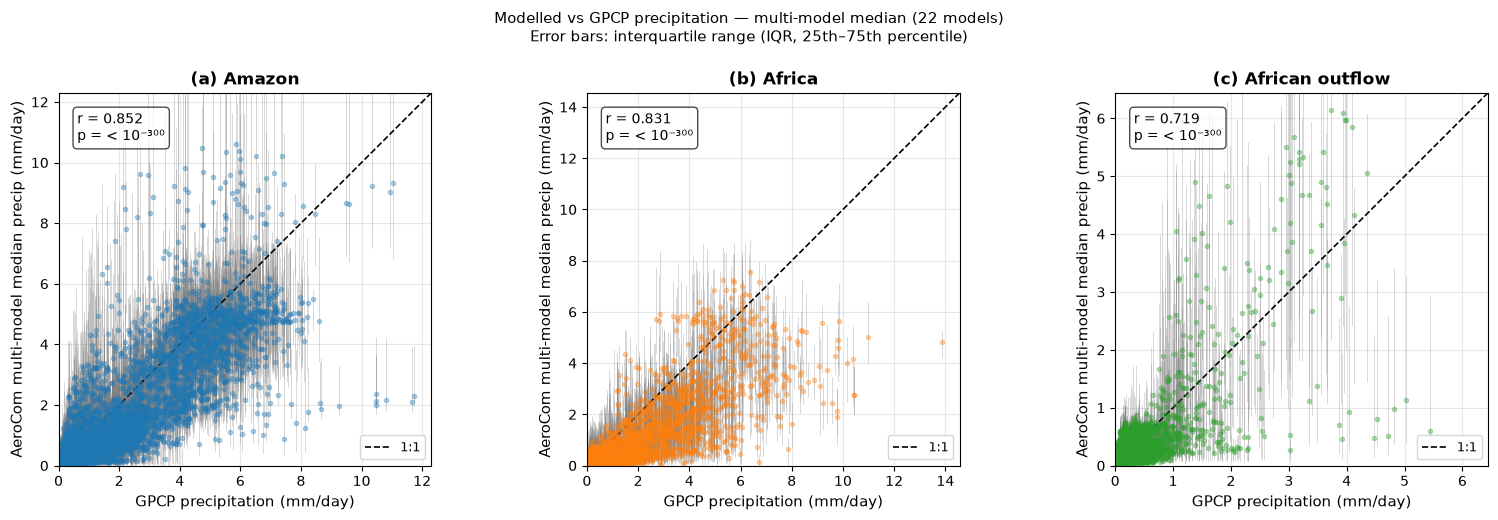

In [23]:
# ── Fig. S4-style scatter: GPCP vs multi-model median precip ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

panel_keys = ["amazon", "africa","outflow_af"]
colors = {"amazon": "tab:blue", "africa": "tab:orange", "outflow_af": "tab:green"}

for ax, rname in zip(axes, panel_keys):
    cfg  = fig_s4_regions[rname]
    sd   = scatter_data[rname]
    gpcp_vals   = sd["gpcp"]
    median_vals = sd["median"]
    e_lo        = sd["e_lo"]
    e_hi        = sd["e_hi"]
    r_val, p_val = sd["r"], sd["p"]
    color = colors[rname]

    # Error bars (IQR asymmetric)
    ax.errorbar(
        gpcp_vals, median_vals,
        yerr=[e_lo, e_hi],
        fmt="o", color=color, ecolor="gray",
        alpha=0.35, markersize=3, linewidth=0.6,
        label="_nolegend_",
    )

    # 1:1 dashed line
    max_val = max(gpcp_vals.max(), median_vals.max()) * 1.05
    ax.plot([0, max_val], [0, max_val], "k--", linewidth=1.2, label="1:1")

    # Annotate r and p-value
    p_str = f"{p_val:.2e}" if p_val >= 1e-300 else "< 10\u207b\u00b3\u2070\u2070"
    annot = "r = {:.3f}\np = {}".format(r_val, p_str)
    ax.text(0.05, 0.95, annot,
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_xlabel("GPCP precipitation (mm/day)", fontsize=11)
    ax.set_ylabel("AeroCom multi-model median precip (mm/day)", fontsize=11)
    ax.set_title("{} {}".format(cfg["panel"], cfg["label"]), fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

n_models = scatter_data["amazon"]["n_models"]
fig.suptitle(
    "Modelled vs GPCP precipitation \u2014 multi-model median ({} models)\n"
    "Error bars: interquartile range (IQR, 25th\u201375th percentile)".format(n_models),
    fontsize=11, y=1.01,
)
plt.tight_layout()

fig_path = os.path.join(project_root, "notebooks", "GPCP_vs_AeroCom_median_precip.png")
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved figure to {}".format(fig_path))
plt.show()


## 6. Monthly precipitation vs. collocated POLDER/model AOD

For the African fire season (June-September), we compare the GPCP monthly precipitation with collocated POLDER AOD_550 and one AeroCom model (ECHAM6-HAM2). The link to the aerosol analysis is that wet-season scavenging can suppress aerosol loading, so a negative correlation is often expected in strongly seasonal regions.

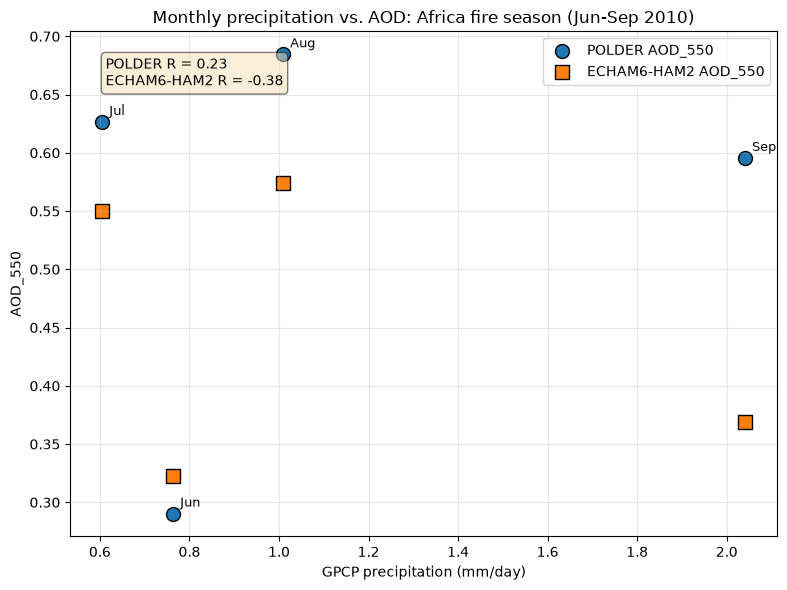

Monthly means:
     month  GPCP_precip_mm_day  POLDER_AOD_550  ECHAM6-HAM2_AOD_550
0  2010-06               0.764           0.290                0.322
1  2010-07               0.605           0.627                0.550
2  2010-08               1.009           0.685                0.574
3  2010-09               2.041           0.596                0.369


In [18]:
col_file = os.path.join(project_root, 'Data/AP3_POLDER_Collocated', 'POLDER_GRASP_coloc_3h_AP3_2010_v1.parquet')
region = 'africa'
mask = mask_registry[region]
lon_min, lon_max = mask.attrs['lon_range']
lat_min, lat_max = mask.attrs['lat_range']

# Read only the columns needed for this comparison
model_col = 'AOD_550_ECHAM6-HAM2_AP3-CTRL2016-PD'
cols = ['time', 'longitude', 'latitude', 'AOD_550', model_col]
df = pd.read_parquet(col_file, columns=cols)
df['month'] = df['time'].dt.to_period('M')

# Spatial subset for the selected region (supports dateline-wrapping longitudes)
if lon_min <= lon_max:
    mask_lon = (df['longitude'] >= lon_min) & (df['longitude'] <= lon_max)
else:
    mask_lon = (df['longitude'] >= lon_min) | (df['longitude'] <= lon_max)
mask_lat = (df['latitude'] >= lat_min) & (df['latitude'] <= lat_max)
df_reg = df[mask_lon & mask_lat].copy()

# Monthly means (fire season only)
months = [pd.Period('2010-06'), pd.Period('2010-07'), pd.Period('2010-08'), pd.Period('2010-09')]
precip_vals = []
aod_polder = []
aod_model = []
for m in months:
    p = ts_dict[region].loc[ts_dict[region].index.to_period('M') == m]
    precip_vals.append(float(p.iloc[0]) if len(p) > 0 else np.nan)
    aod_polder.append(float(df_reg[df_reg['month'] == m]['AOD_550'].mean()))
    aod_model.append(float(df_reg[df_reg['month'] == m][model_col].mean()))

precip_vals = np.array(precip_vals)
aod_polder = np.array(aod_polder)
aod_model = np.array(aod_model)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(precip_vals, aod_polder, s=100, color='tab:blue', edgecolor='k', label='POLDER AOD_550')
ax.scatter(precip_vals, aod_model, s=100, color='tab:orange', edgecolor='k', marker='s', label='ECHAM6-HAM2 AOD_550')
for i, month in enumerate(months):
    ax.annotate(month.strftime('%b'), (precip_vals[i], aod_polder[i]), textcoords='offset points', xytext=(5, 5), fontsize=9)
ax.set_xlabel('GPCP precipitation (mm/day)')
ax.set_ylabel('AOD_550')
ax.set_title('Monthly precipitation vs. AOD: Africa fire season (Jun-Sep 2010)')
ax.legend()
ax.grid(True, alpha=0.3)

# Correlations (n=4, fire season only; interpret with caution)
valid_p = ~np.isnan(precip_vals) & ~np.isnan(aod_polder)
valid_m = ~np.isnan(precip_vals) & ~np.isnan(aod_model)
if np.sum(valid_p) > 2:
    r_p = np.corrcoef(precip_vals[valid_p], aod_polder[valid_p])[0, 1]
    r_m = np.corrcoef(precip_vals[valid_m], aod_model[valid_m])[0, 1]
    ax.text(0.05, 0.95, f'POLDER R = {r_p:.2f}\nECHAM6-HAM2 R = {r_m:.2f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
fig.savefig(os.path.join(project_root, 'notebooks', 'GPCP_precip_vs_AOD_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Monthly means:')
print(pd.DataFrame({
    'month': [m.strftime('%Y-%m') for m in months],
    'GPCP_precip_mm_day': precip_vals,
    'POLDER_AOD_550': aod_polder,
    'ECHAM6-HAM2_AOD_550': aod_model,
}).round(3))

## 7. Summary and caveats

**Converted NetCDF file:** `Data/Prec/GPCP_2010_0-360.nc` contains the full 2010 GPCP monthly dataset with longitude converted from [-180, 180] to [0, 360] and sorted ascending. The main variable is `sat_gauge_precip` (mm/day).

**Plots produced:**
1. Global/annual mean precipitation map for 2010.
2. Monthly time series of global and tropical mean precipitation.
3. Regional maps for Africa, Amazon, African outflow, and the global domain.
4. Monthly scatter of precipitation vs. POLDER/model AOD for the African fire season.

**Caveats:**
- GPCP is a monthly product; any comparison with 3-hourly POLDER/model AOD uses monthly aggregation.
- The regional masks are box masks on the GPCP 0.5 grid; coastlines and topography are not resolved.
- The African outflow region wraps around 0 longitude; the map extent is shown with a central longitude that crosses the dateline.
- Some model AOD columns in the collocation file are entirely NaN (e.g., CAM5_CTRL2016, IMPACT, MIROC-SPRINTARS, SPRINTARS-T213); the example above uses ECHAM6-HAM2, which has full coverage in this region.
- Precipitation is a proxy for wet deposition/scavenging, but the relationship with AOD is complex and region-dependent.